In [ ]:
# LAB ASSIGNMENT - 4
# Logistic Regression
# Wisconsin Diagnostic Breast Cancer (WDBC) Dataset
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [ ]:
# Ten nuclear characteristics
feature_names = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave_points",
    "symmetry",
    "fractal_dimension"
]

# First two columns
column_names = [
    "id",
    "diagnosis"
]

# Add mean, SE and worst features
for measurement in ["mean", "se", "worst"]:
    for feature in feature_names:
        column_names.append(
            f"{measurement}_{feature}"
        )

# Display column names
print("Total number of columns:", len(column_names))
print("\nColumn names:")
print(column_names)

Total number of columns: 32

Column names:
['id', 'diagnosis', 'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'se_radius', 'se_texture', 'se_perimeter', 'se_area', 'se_smoothness', 'se_compactness', 'se_concavity', 'se_concave_points', 'se_symmetry', 'se_fractal_dimension', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']


In [ ]:
# Load WDBC dataset

df = pd.read_csv(
    "/content/wdbc.data",
    header=None,
    names=column_names
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("\nFirst five rows:")
print(df.head())


First five rows:
         id diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  worst_radius  worst_texture  worst_p

In [ ]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(569, 32)


In [ ]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   mean_radius              569 non-null    float64
 3   mean_texture             569 non-null    float64
 4   mean_perimeter           569 non-null    float64
 5   mean_area                569 non-null    float64
 6   mean_smoothness          569 non-null    float64
 7   mean_compactness         569 non-null    float64
 8   mean_concavity           569 non-null    float64
 9   mean_concave_points      569 non-null    float64
 10  mean_symmetry            569 non-null    float64
 11  mean_fractal_dimension   569 non-null    float64
 12  se_radius                569 non-null    float64
 13  se_texture               569 non-null    float64
 14  se_p

In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id                           int64
diagnosis                   object
mean_radius                float64
mean_texture               float64
mean_perimeter             float64
mean_area                  float64
mean_smoothness            float64
mean_compactness           float64
mean_concavity             float64
mean_concave_points        float64
mean_symmetry              float64
mean_fractal_dimension     float64
se_radius                  float64
se_texture                 float64
se_perimeter               float64
se_area                    float64
se_smoothness              float64
se_compactness             float64
se_concavity               float64
se_concave_points          float64
se_symmetry                float64
se_fractal_dimension       float64
worst_radius               float64
worst_texture              float64
worst_perimeter            float64
worst_area                 float64
worst_smoothness           float64
worst_compactness          float64
worst_c

In [ ]:
print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())


First 5 Rows:


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Last 5 Rows:


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
print(df.head())
print(df.tail())

         id diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  worst_radius  worst_texture  worst_perimeter  worst_ar

In [ ]:
print("\nDiagnosis Values:")
print(df["diagnosis"].value_counts())


Diagnosis Values:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Select the 30 actual input features

feature_columns = column_names[2:]
print("Number of input features:", len(feature_columns))
summary_statistics = pd.DataFrame({
    "Mean": df[feature_columns].mean(),
    "Median": df[feature_columns].median(),
    "Standard Deviation": df[feature_columns].std(),
    "Minimum": df[feature_columns].min(),
    "Maximum": df[feature_columns].max()
})

print("\nSummary Statistics:")
display(summary_statistics)
print(df[feature_columns].describe())

Number of input features: 30

Summary Statistics:


,Mean,Median,Standard Deviation,Minimum,Maximum
mean_radius,14.127292,13.370000,3.524049,6.981000,28.11000
mean_texture,19.289649,18.840000,4.301036,9.710000,39.28000
mean_perimeter,91.969033,86.240000,24.298981,43.790000,188.50000
mean_area,654.889104,551.100000,351.914129,143.500000,2501.00000
mean_smoothness,0.096360,0.095870,0.014064,0.052630,0.16340
mean_compactness,0.104341,0.092630,0.052813,0.019380,0.34540
mean_concavity,0.088799,0.061540,0.079720,0.000000,0.42680
mean_concave_points,0.048919,0.033500,0.038803,0.000000,0.20120
mean_symmetry,0.181162,0.179200,0.027414,0.106000,0.30400
mean_fractal_dimension,0.062798,0.061540,0.007060,0.049960,0.09744


       mean_radius  mean_texture  mean_perimeter    mean_area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [ ]:
print("\nMissing Values:")
missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)
if df.isnull().sum().sum() == 0:
    print("\nConclusion: No missing values found.")
else:
    print("\nConclusion: Missing values are present.")


Missing Values:
id                         0
diagnosis                  0
mean_radius                0
mean_texture               0
mean_perimeter             0
mean_area                  0
mean_smoothness            0
mean_compactness           0
mean_concavity             0
mean_concave_points        0
mean_symmetry              0
mean_fractal_dimension     0
se_radius                  0
se_texture                 0
se_perimeter               0
se_area                    0
se_smoothness              0
se_compactness             0
se_concavity               0
se_concave_points          0
se_symmetry                0
se_fractal_dimension       0
worst_radius               0
worst_texture              0
worst_perimeter            0
worst_area                 0
worst_smoothness           0
worst_compactness          0
worst_concavity            0
worst_concave_points       0
worst_symmetry             0
worst_fractal_dimension    0
dtype: int64

Total Missing Values: 0

Conclusion: No m

In [ ]:
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)
df = df.drop_duplicates()
duplicate_ids = df["id"].duplicated().sum()
print("Number of duplicate IDs:", duplicate_ids)


Number of duplicate rows: 0
Number of duplicate IDs: 0


In [ ]:
outlier_summary = []
for column in feature_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()
    outlier_summary.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outlier_count
    ])
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)
print("\nOutlier Analysis:")
display(outlier_df)


Outlier Analysis:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,mean_radius,11.700000,15.780000,4.080000,5.580000,21.900000,14
1,mean_texture,16.170000,21.800000,5.630000,7.725000,30.245000,7
2,mean_perimeter,75.170000,104.100000,28.930000,31.775000,147.495000,13
3,mean_area,420.300000,782.700000,362.400000,-123.300000,1326.300000,25
4,mean_smoothness,0.086370,0.105300,0.018930,0.057975,0.133695,6
5,mean_compactness,0.064920,0.130400,0.065480,-0.033300,0.228620,16
6,mean_concavity,0.029560,0.130700,0.101140,-0.122150,0.282410,18
7,mean_concave_points,0.020310,0.074000,0.053690,-0.060225,0.154535,10
8,mean_symmetry,0.161900,0.195700,0.033800,0.111200,0.246400,15
9,mean_fractal_dimension,0.057700,0.066120,0.008420,0.045070,0.078750,15


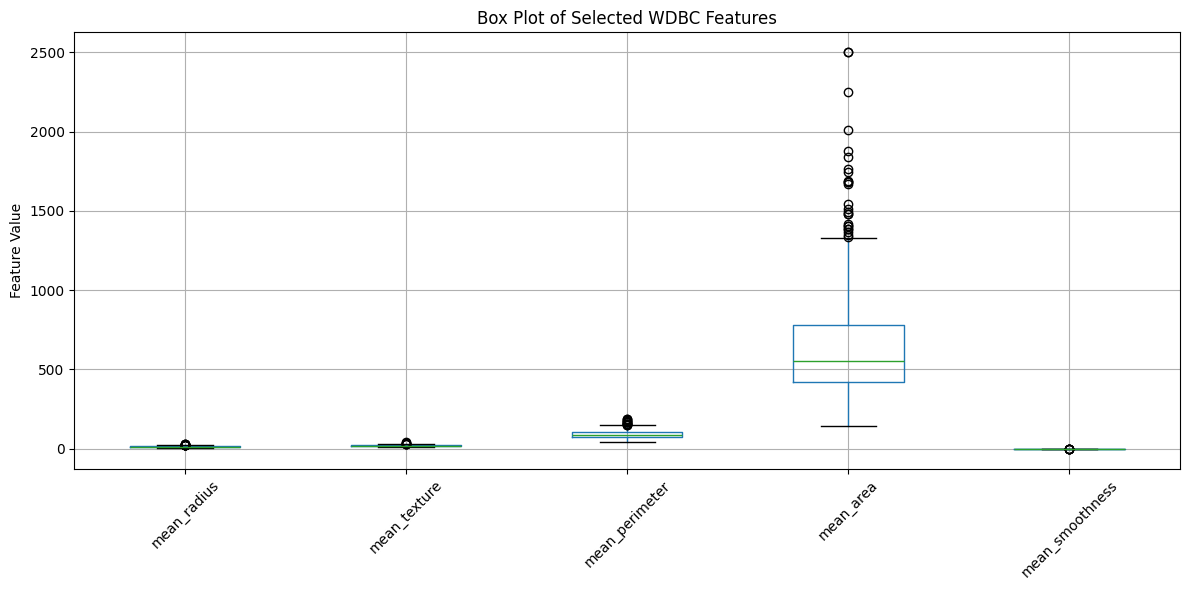

In [ ]:
selected_features = [
    "mean_radius",
    "mean_texture",
    "mean_perimeter",
    "mean_area",
    "mean_smoothness"
]
plt.figure(figsize=(12, 6))
df[selected_features].boxplot()
plt.title("Box Plot of Selected WDBC Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

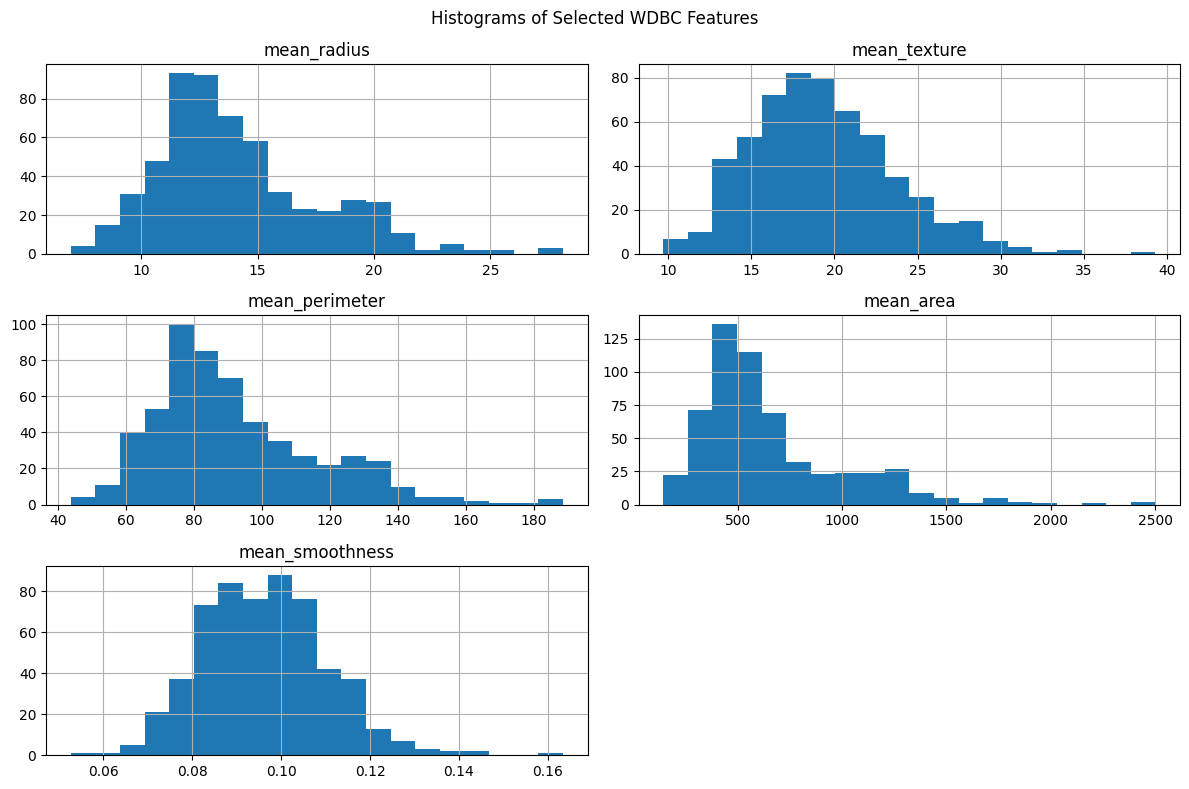

In [ ]:
df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)
plt.suptitle(
    "Histograms of Selected WDBC Features"
)
plt.tight_layout()
plt.show()

In [ ]:
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})
print("\nEncoded Diagnosis:")
print(df["diagnosis"].value_counts())


Encoded Diagnosis:
diagnosis
0    357
1    212
Name: count, dtype: int64



Class Counts:
diagnosis
0    357
1    212
Name: count, dtype: int64

Class Percentages:
diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


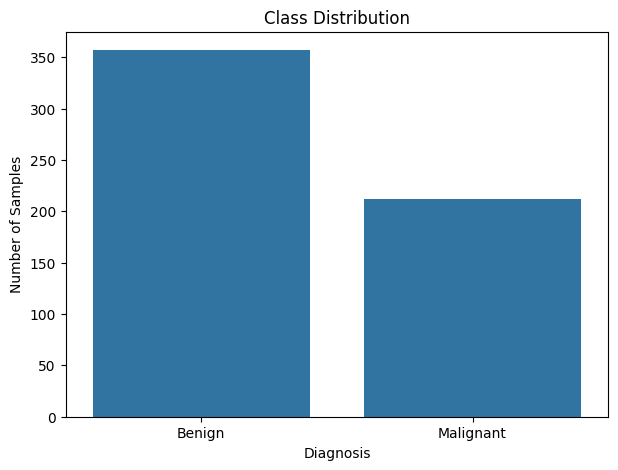

In [ ]:
class_counts = df["diagnosis"].value_counts()

class_percentages = (
    df["diagnosis"]
    .value_counts(normalize=True)
    * 100
)

print("\nClass Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.xticks(
    [0, 1],
    ["Benign", "Malignant"]
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

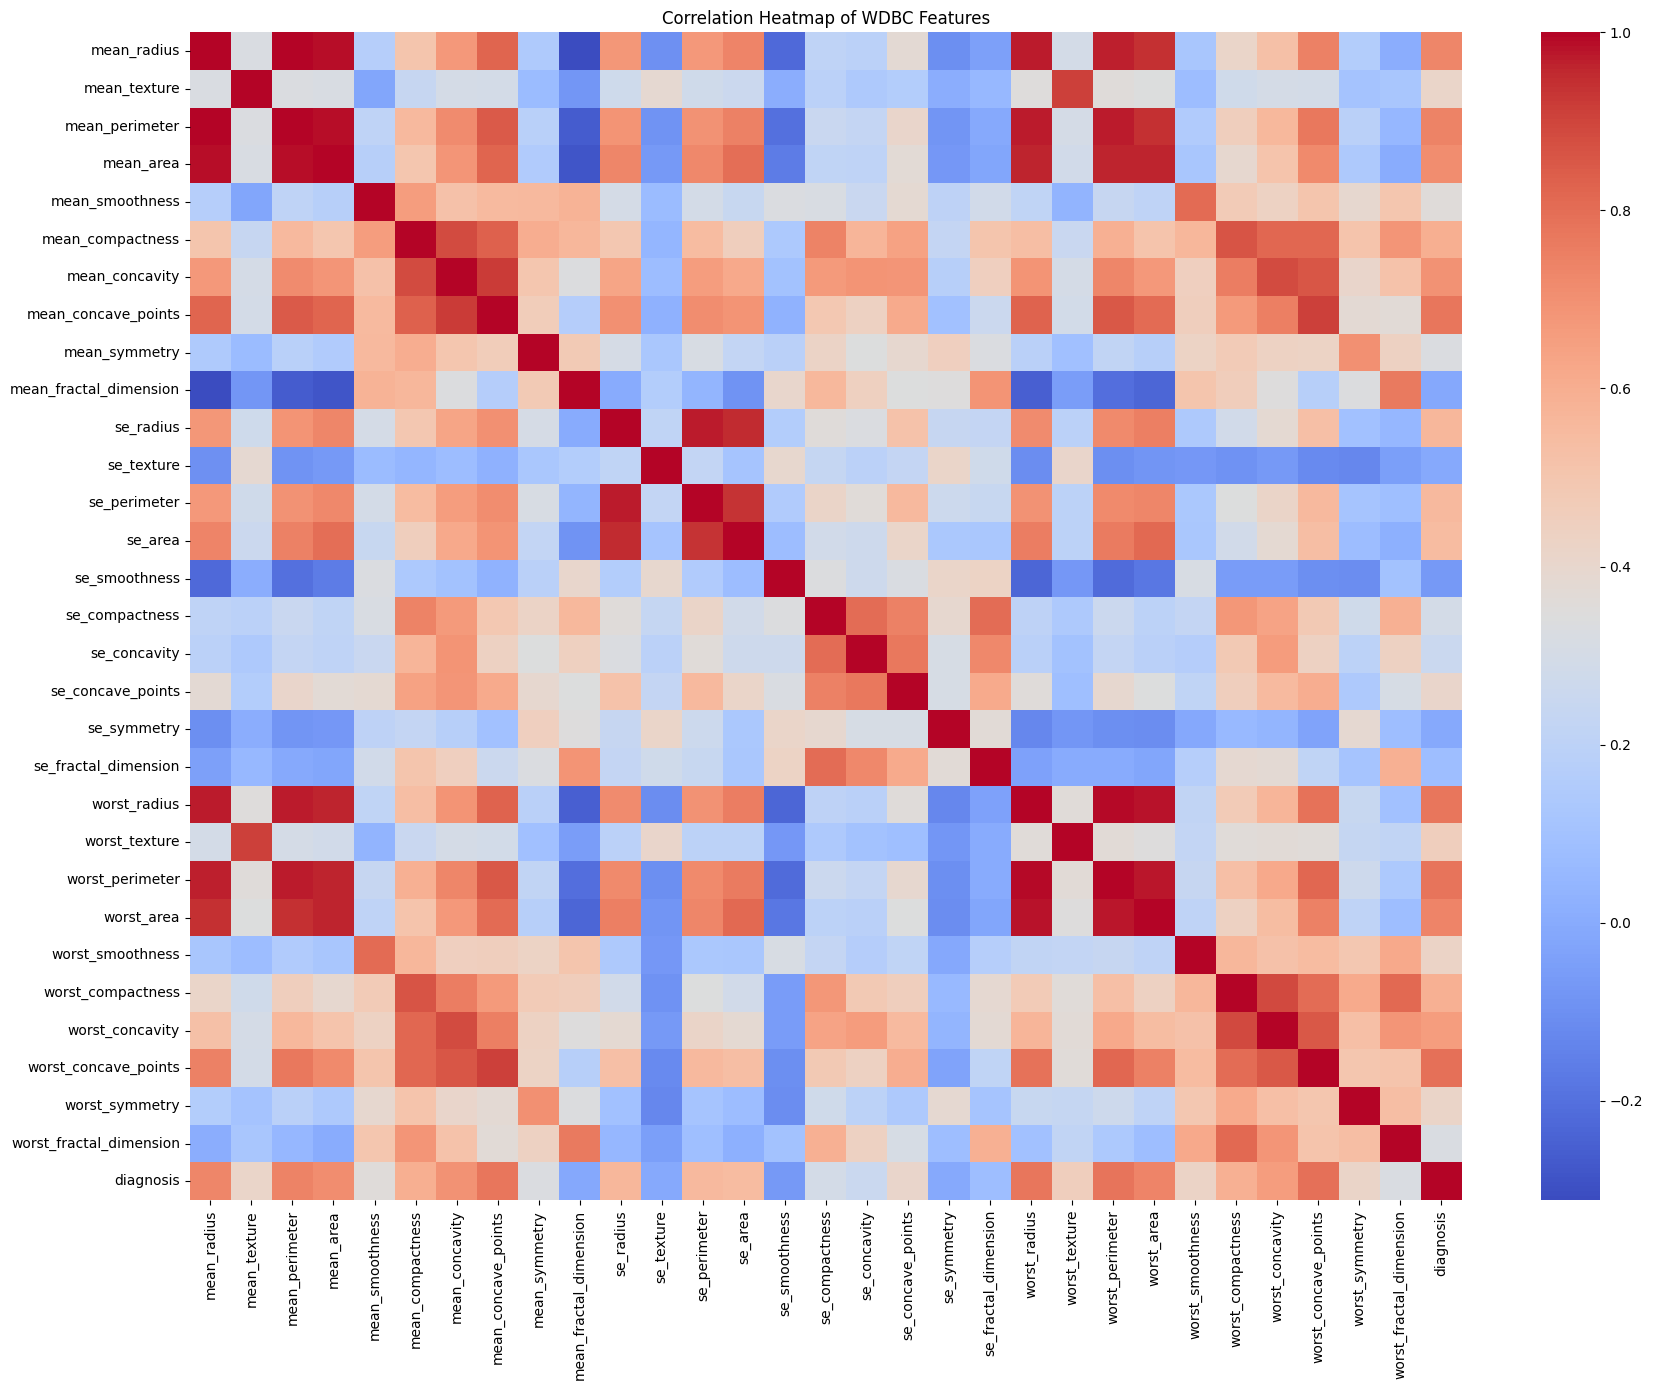

In [ ]:
correlation_matrix = df[
    feature_columns + ["diagnosis"]
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title(
    "Correlation Heatmap of WDBC Features"
)

plt.tight_layout()
plt.show()

In [ ]:
X = df[feature_columns]

y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (455, 30)
Testing data: (114, 30)

Training target: (455,)
Testing target: (114,)


In [ ]:
print("\nOriginal Class Distribution:")
print(y.value_counts(normalize=True))

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))


Original Class Distribution:
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64

Training Class Distribution:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing Class Distribution:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

In [ ]:
model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


In [32]:
y_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

print("\nPredicted probability of malignant class:")
print(y_probability)


Predicted probability of malignant class:
[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02 9.30905953e-01 7.28319772e-05
 9.99999899e-01 4.39449272e-03 7.75262630e-03 1.70641370e-06
 6.14294329e-02 3.62811536e-04 2.21762013e-01 5.07279789e-05
 1.26622816e-03 4.30342121e-03 9.99999581e-01 9.98321524e-01
 7.57606906e-01 2.05880632e-04 1.68680282e-04 9.69171419e-01
 9.96639529e-01 9.99579644e-01 9.99991854e-01 2.37027672e-03
 9.99964222e-01 9.99954679e-01 2.66371788e-04 1.39030746e-02
 2.02020415e-03 3.20211147e-06 9.90930715e-01 9.31932725e-02
 1.25745605e-04 3.52528144e-04 8.52325081e-01 2.51409506e-03
 1.08172442e-02 9.54067888e-01 7.56926419e-02 9.98508631e-01
 5.69898683e-05 1.11541174e-03 9.99999992e-01 9.98457814e-01
 7.12763094e-03 1.05057651e-03 1.21417298e-04 9.88025845e-01
 5.20634356e-02 1.78092127e-06 4.96022080e-04 9.99999998e-01
 1.51720715e-02 7.33385576e-02 9.01754631e

In [33]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9649
Accuracy: 96.49%


In [34]:
precision_benign = precision_score(
    y_test,
    y_pred,
    pos_label=0
)
precision_malignant = precision_score(
    y_test,
    y_pred,
    pos_label=1
)
print(
    f"Precision - Benign: {precision_benign:.4f}"
)
print(
    f"Precision - Malignant: {precision_malignant:.4f}"
)

Precision - Benign: 0.9595
Precision - Malignant: 0.9750


In [35]:
recall_benign = recall_score(
    y_test,
    y_pred,
    pos_label=0
)
recall_malignant = recall_score(
    y_test,
    y_pred,
    pos_label=1
)
print(
    f"Recall - Benign: {recall_benign:.4f}"
)
print(
    f"Recall - Malignant: {recall_malignant:.4f}"
)

Recall - Benign: 0.9861
Recall - Malignant: 0.9286


In [43]:
f1_benign = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

f1_malignant = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print(
    f"F1 Score - Benign: {f1_benign:.4f}"
)

print(
    f"F1 Score - Malignant: {f1_malignant:.4f}"
)

F1 Score - Benign: 0.9726
F1 Score - Malignant: 0.9512


In [37]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114




Confusion Matrix:
[[71  1]
 [ 3 39]]


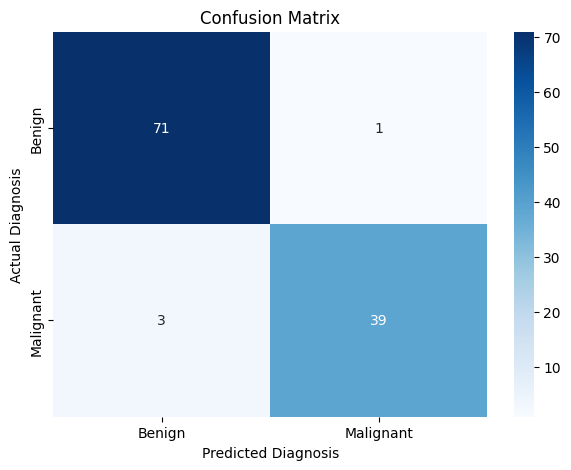

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.show()

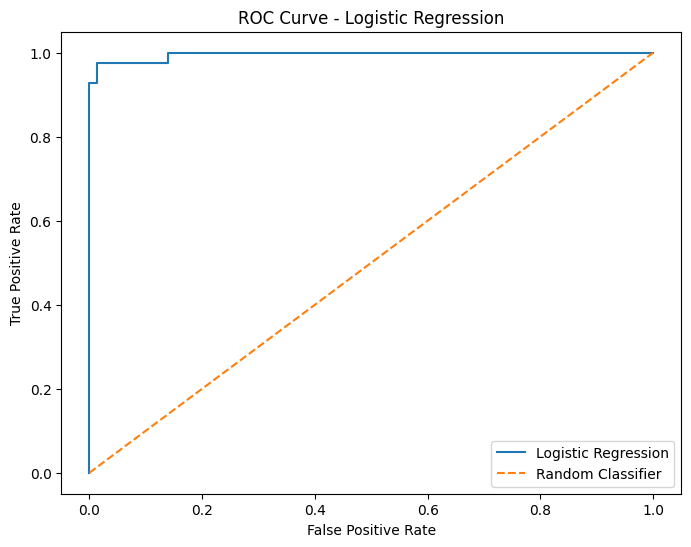

In [39]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.legend()

plt.show()

AUC Score: 0.9960


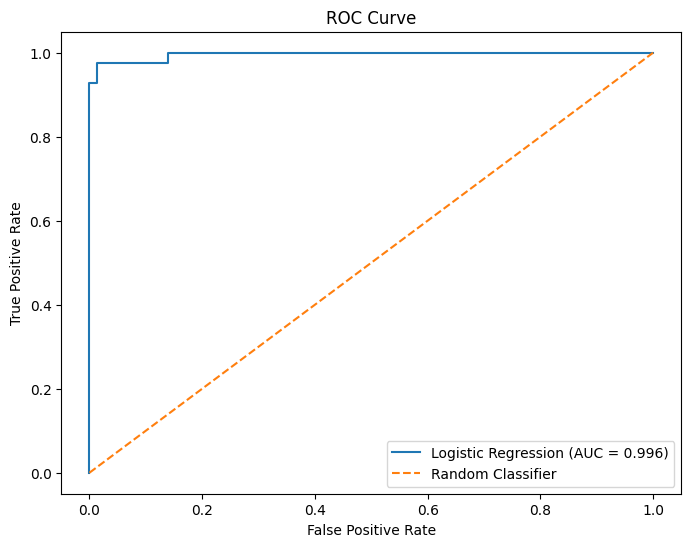

In [40]:
auc_score = roc_auc_score(
    y_test,
    y_probability
)

print(
    f"AUC Score: {auc_score:.4f}"
)
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [44]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Malignant Precision",
        "Malignant Recall",
        "Malignant F1 Score",
        "AUC"
    ],
    "Score": [
        accuracy,
        precision_malignant,
        recall_malignant,
        f1_malignant,
        auc_score
    ]
})

print("\nFinal Model Results:")
display(results)


Final Model Results:


,Metric,Score
0,Accuracy,0.964912
1,Malignant Precision,0.975000
2,Malignant Recall,0.928571
3,Malignant F1 Score,0.951220
4,AUC,0.996032
